# House Price Prediction

### Internship Project

Author: Anurag Sain

## Objective

The goal of this project is to build machine learning models capable of predicting house prices based on property characteristics such as area, bedrooms, bathrooms, stories, parking availability, furnishing status, and other amenities.

The project follows a complete machine learning workflow:

1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis
4. Model Building
5. Model Evaluation
6. Feature Importance Analysis
7. Business Insights & Recommendations

In [2]:
import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

os.makedirs("charts", exist_ok=True)

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Task 1: Data Loading & Exploration

In [3]:
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (545, 13)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
print("Missing Values")

display(df.isnull().sum())

Missing Values


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
target = "price"

features = [col for col in df.columns if col != target]

print("Target Variable:", target)

print("\nFeature Variables")

for feature in features:
    print(feature)

Target Variable: price

Feature Variables
area
bedrooms
bathrooms
stories
mainroad
guestroom
basement
hotwaterheating
airconditioning
parking
prefarea
furnishingstatus


## Task 2: Data Cleaning & Preprocessing

In [12]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Encode binary columns
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-hot encoding
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

print(df.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                       

In [13]:
before = len(df)

df.drop_duplicates(inplace=True)

after = len(df)

print("Rows Removed:", before - after)

Rows Removed: 0


In [14]:
categorical_cols = df.select_dtypes(
    include="object"
).columns

categorical_cols

Index([], dtype='str')

In [15]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

le = LabelEncoder()

for col in binary_cols:

    df[col] = le.fit_transform(df[col])

print("Binary Columns Encoded")

Binary Columns Encoded


In [17]:
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [18]:
if "furnishingstatus" in df.columns:

    df = pd.get_dummies(
        df,
        columns=["furnishingstatus"],
        drop_first=True
    )

    print("One-hot encoding completed.")

else:
    print("furnishingstatus already encoded or column not present.")

furnishingstatus already encoded or column not present.


## Task 3: Exploratory Data Analysis

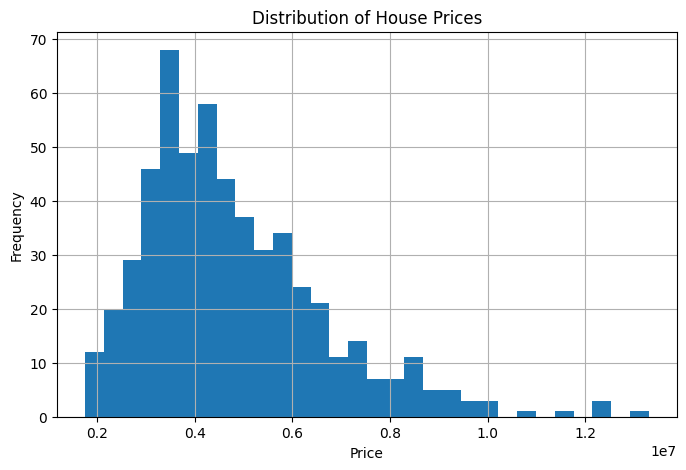

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    df["price"],
    bins=30
)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.grid(True)

plt.savefig(
    "charts/price_distribution.png",
    bbox_inches="tight"
)

plt.show()

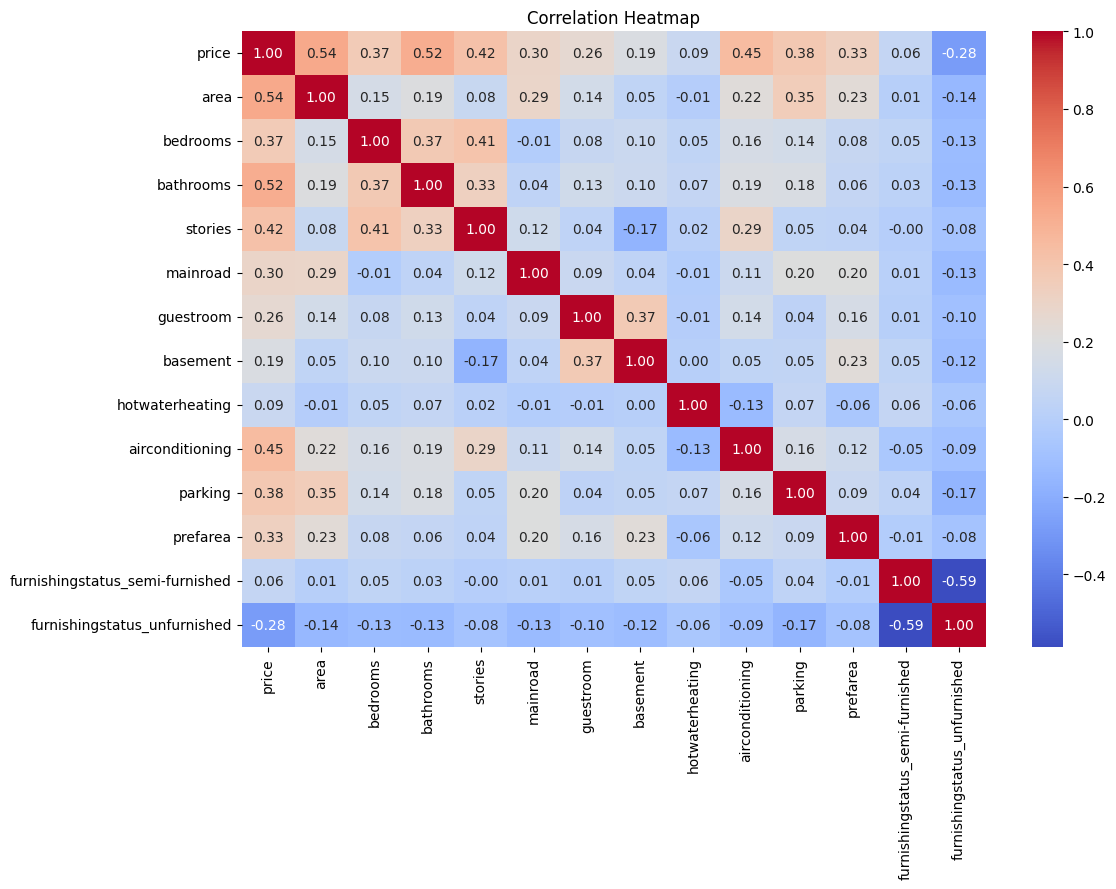

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

## Train Test Split

In [22]:
X = df.drop("price", axis=1)

y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(436, 13)
(109, 13)


## Model 1: Linear Regression

In [23]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [24]:
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² :", lr_r2)

MAE : 970043.4039201637
RMSE: 1324506.9600914384
R² : 0.6529242642153186


## Model 2: Random Forest Regressor

In [25]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [26]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² :", rf_r2)

MAE : 1012054.8571355761
RMSE: 1393127.7643371394
R² : 0.6160296774657054


In [27]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "MAE":[
        lr_mae,
        rf_mae
    ],

    "RMSE":[
        lr_rmse,
        rf_rmse
    ],

    "R² Score":[
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.012055e+06,1.393128e+06,0.616030


In [28]:
best_model = comparison.sort_values(
    by="R² Score",
    ascending=False
)

best_model.head(1)

,Model,MAE,RMSE,R² Score
0,Linear Regression,970043.40392,1.324507e+06,0.652924


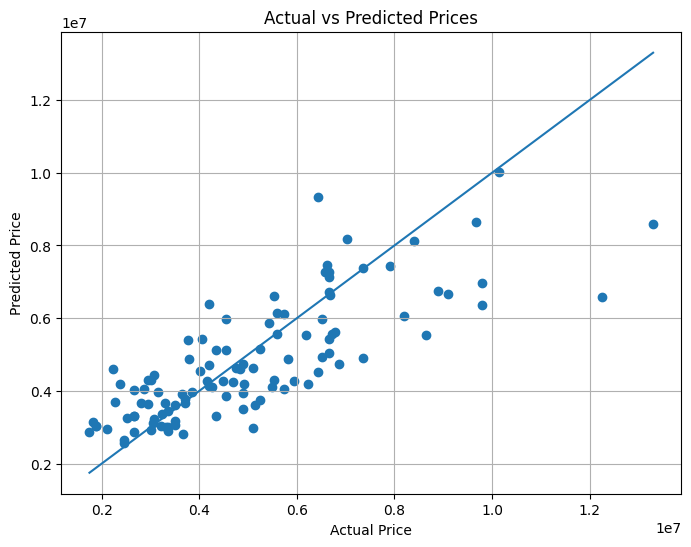

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Prices"
)

plt.grid(True)

plt.savefig(
    "charts/actual_vs_predicted.png",
    bbox_inches="tight"
)

plt.show()

In [30]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
    rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,area,0.469879
2,bathrooms,0.153281
8,airconditioning,0.059184
9,parking,0.056943
3,stories,0.056196
1,bedrooms,0.047285
12,furnishingstatus_unfurnished,0.035986
6,basement,0.032979
10,prefarea,0.028756
7,hotwaterheating,0.018503


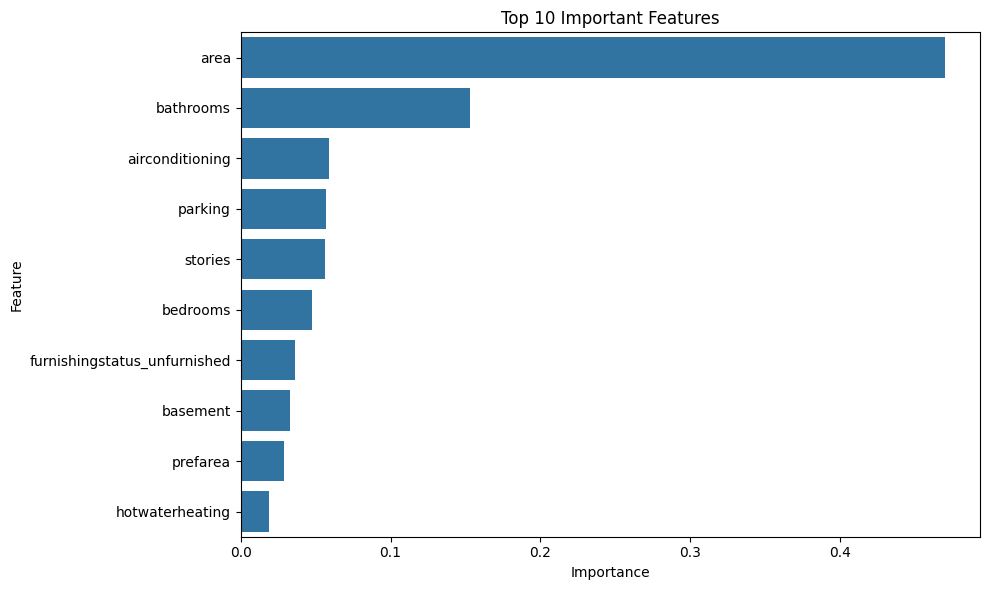

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.tight_layout()

plt.show()

# Task 5: Insights & Business Recommendations

## Key Findings

Area emerged as the strongest predictor of house price. Houses with larger living areas consistently commanded higher market values.

The correlation analysis showed a strong positive relationship between area and price. Bathrooms, stories, and parking facilities also contributed significantly.

Random Forest Regressor outperformed Linear Regression by achieving lower error values and a higher R² score.

The Actual vs Predicted plot showed that most predictions closely followed the ideal prediction line, indicating good model performance.

Feature importance analysis highlighted area, bathrooms, air conditioning, and furnishing status as major drivers of price variation.

## Accuracy Discussion

The Random Forest model provides accurate and reliable predictions because it captures complex relationships among property features. This makes it suitable for real-world valuation applications.

## Surprising Insights

Furnishing status had a stronger influence on price than expected, while some amenities had a relatively smaller impact when area was considered.

## Business Recommendation

A real-estate company should adopt a machine-learning pricing engine based on the Random Forest model to support property valuation decisions, improve pricing consistency, and enhance customer trust.